In [2]:
from typing import Set, Tuple

import numpy as np
import pandas as pd

from soccer_one_twos_extractor.constants.fields import F
from soccer_one_twos_extractor.pipeline.pipe import MetricPipeline
from soccer_one_twos_extractor.utils.plotting import (
    plot_one_twos_heatmap,
    plot_one_twos_per_90,
    plot_onetwos_chance_creation,
    plot_onetwos_scatter_player,
    plot_season_avg_one_twos,
    plot_team_one_twos,
)

# Folder inputs

In [3]:
data_folder_path = "../data"
logos_folder_path = "../assets"
fbref_csv_file = "fbref_playersdb.csv"

# Metric Extraction

### Helper functions

In [4]:
def get_duos_common_minutes(
    association_metric_df: pd.DataFrame,
    players_data: pd.DataFrame,
) -> pd.DataFrame:
    """
    Compute the total minutes two players (who formed a one–two) were
    simultaneously on the pitch for the same team and match.
    """
    d = players_data.copy()

    # --- 1) Build the set of undirected pairs from one–twos (by names) ---
    pairs: Set[Tuple[str, str]] = {
        tuple(sorted((str(a), str(b))))
        for a, b in association_metric_df[["player_A_name", "player_B_name"]]
        .dropna()
        .itertuples(index=False, name=None)
    }

    # --- 2) Ensure on/off seconds exist (MM:SS -> seconds) ---
    if "player_on_s" not in d.columns or "player_off_s" not in d.columns:
        for col in ["player_on", "player_off"]:
            mmss = d[col].fillna("0:00").astype(str).str.split(":", expand=True)
            mins = pd.to_numeric(mmss[0], errors="coerce").fillna(0).astype(int)
            secs = pd.to_numeric(mmss[1], errors="coerce").fillna(0).astype(int)
            d[f"{col}_s"] = mins * 60 + secs

    # --- 3) Self-join by (game, team) to form all within-team duos per match ---
    cm = d.merge(d, on=[F.GAME_ID, F.TEAM_NAME], suffixes=("_x", "_y"))

    # Keep unique player pairs (no self, no duplicates): order by player_id
    cm = cm[cm["player_id_x"] < cm["player_id_y"]].copy()
    cm = cm.dropna(subset=["player_x", "player_y"])

    # Undirected pair key by names to match association_metric_df
    cm["pair"] = list(
        map(
            lambda a, b: tuple(sorted((str(a), str(b)))), cm["player_x"], cm["player_y"]
        )
    )

    # --- 4) Overlapping minutes for the pair within the match ---
    cm["overlap"] = (
        np.minimum(cm["player_off_s_x"], cm["player_off_s_y"])
        - np.maximum(cm["player_on_s_x"], cm["player_on_s_y"])
    ).clip(lower=0) / 60.0  # minutes

    # Only pairs that actually formed a one–two
    cm = cm[cm["pair"].isin(pairs)]

    # --- 5) Aggregate across matches, split back to two columns, round ---
    result = (
        cm.groupby(["pair", F.TEAM_NAME], as_index=False)["overlap"]
        .sum()
        .rename(columns={"overlap": "common_minutes"})
    )
    result[["player_1", "player_2"]] = pd.DataFrame(
        result["pair"].tolist(), index=result.index
    )
    result["common_minutes"] = result["common_minutes"].round(2)

    return result[["player_1", "player_2", F.TEAM_NAME, "common_minutes"]]


def merge_one_twos_with_player_names(
    one_twos_df: pd.DataFrame, players_df: pd.DataFrame
) -> pd.DataFrame:
    """
    Merge one-twos event data with player names based on player IDs.
    """
    merged = one_twos_df.merge(
        players_df[[F.GAME_ID, F.TEAM_ID, F.PLAYER_ID, "player", "pos"]].rename(
            columns={
                F.PLAYER_ID: f"{F.PLAYER_ID}_A",
                "player": "player_A_name",
                "pos": "player_A_position",
            }
        ),
        on=[F.GAME_ID, F.TEAM_ID, f"{F.PLAYER_ID}_A"],
        how="left",
    ).merge(
        players_df[[F.GAME_ID, F.TEAM_ID, F.PLAYER_ID, "player", "pos"]].rename(
            columns={
                F.PLAYER_ID: f"{F.PLAYER_ID}_B",
                "player": "player_B_name",
                "pos": "player_B_position",
            }
        ),
        on=[F.GAME_ID, F.TEAM_ID, f"{F.PLAYER_ID}_B"],
        how="left",
    )
    return merged

### Metric pipeline

In [5]:
_pipe = MetricPipeline(
    data_folder=data_folder_path,
    external_player_file=fbref_csv_file,
    min_progression_ratio_pct=0.25,
    max_time_diff=5,
    max_player_b_ball_carry_distance=7,
    n_jobs=8,
)

(
    events_df,
    players_df,
    progressive_one_twos_df,
) = _pipe.parallel_run()

Parsing matches: 100%|██████████| 380/380 [00:38<00:00,  9.85it/s]


In [6]:
# Merge progressive one twos with player names data
progressive_one_twos_df_ = merge_one_twos_with_player_names(
    progressive_one_twos_df, players_df
)

# Get one twos pairs common minutes
onetwos_pairs_df = get_duos_common_minutes(progressive_one_twos_df_, players_df)

# LALIGA 22-23 Progressive One twos Analysis

### One twos preview

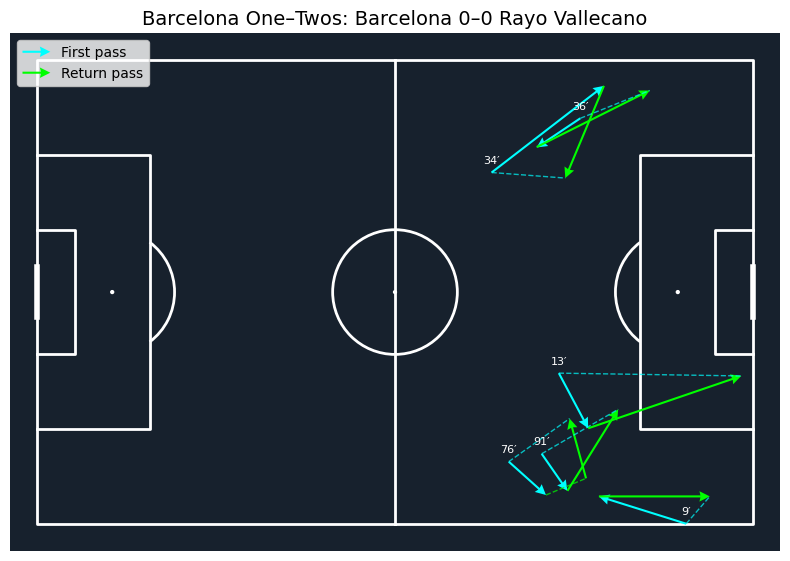

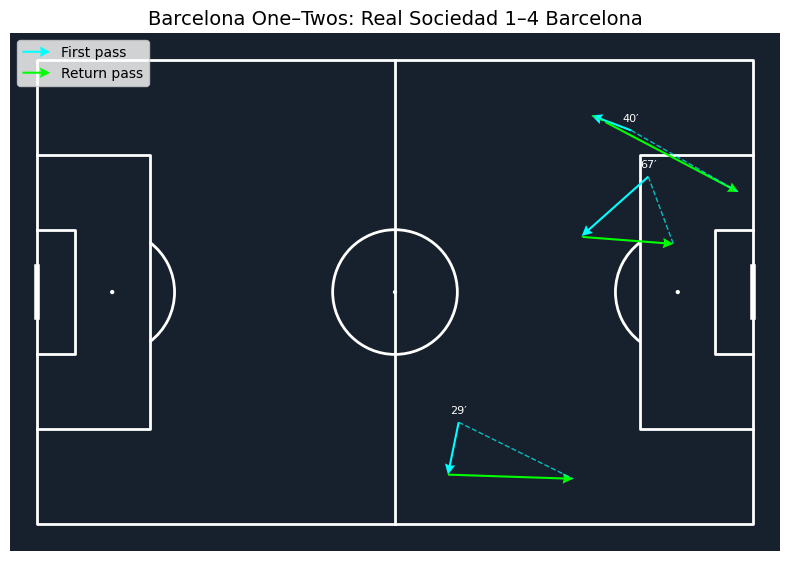

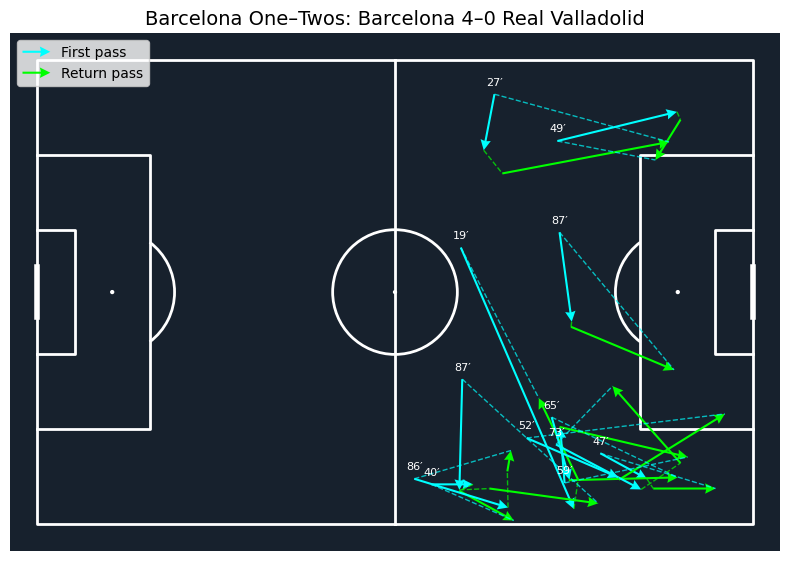

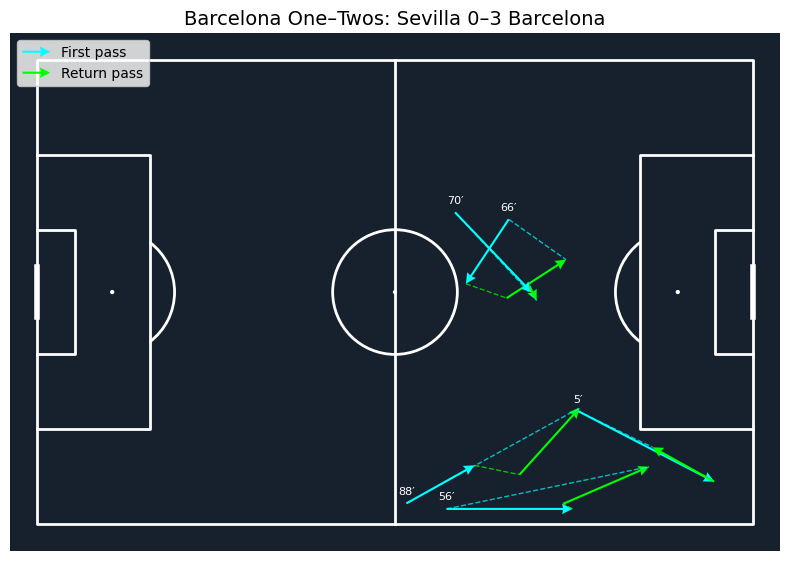

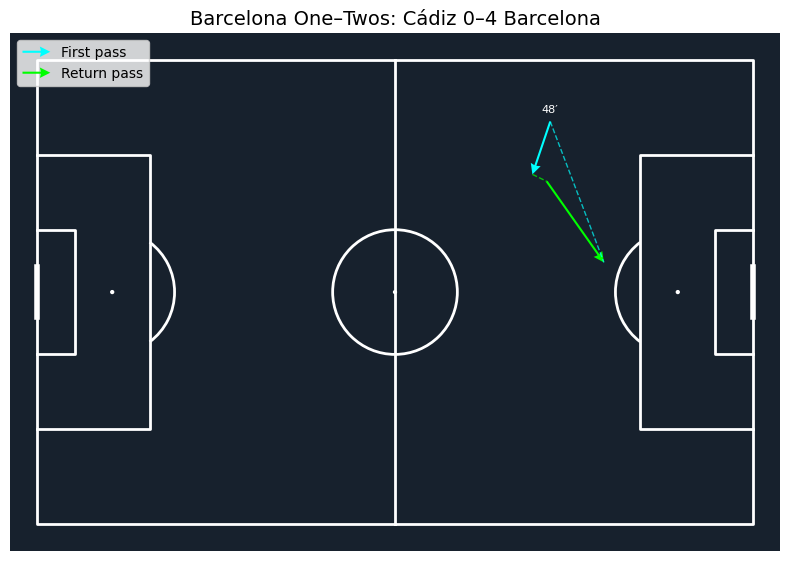

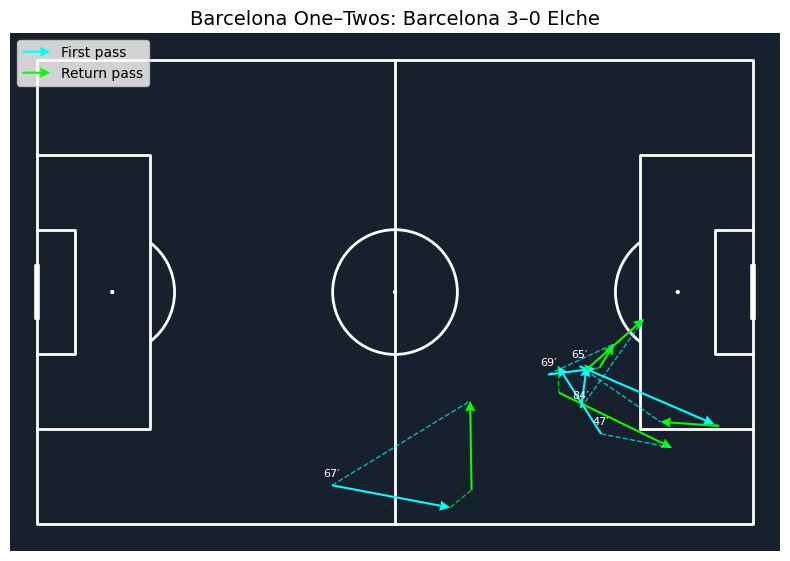

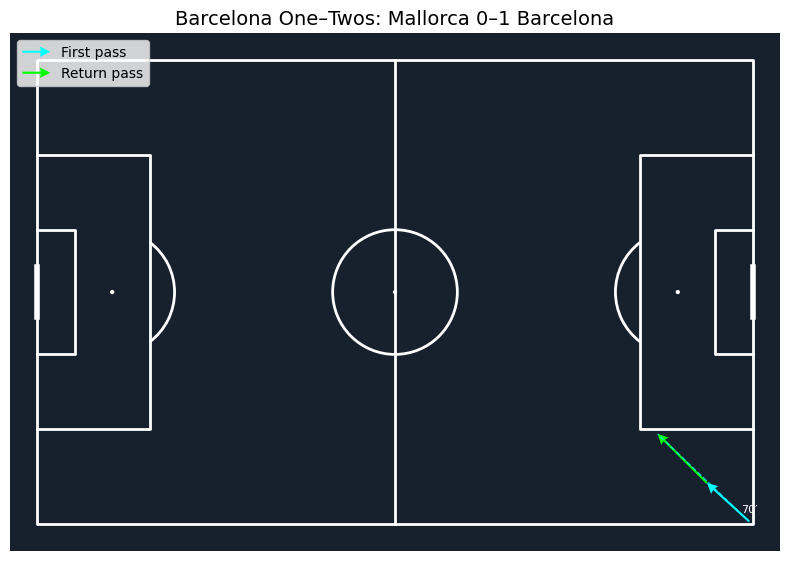

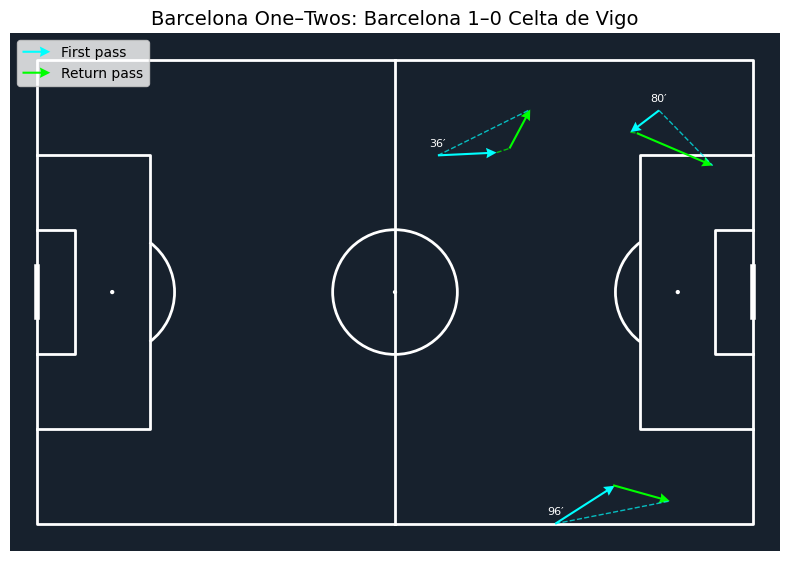

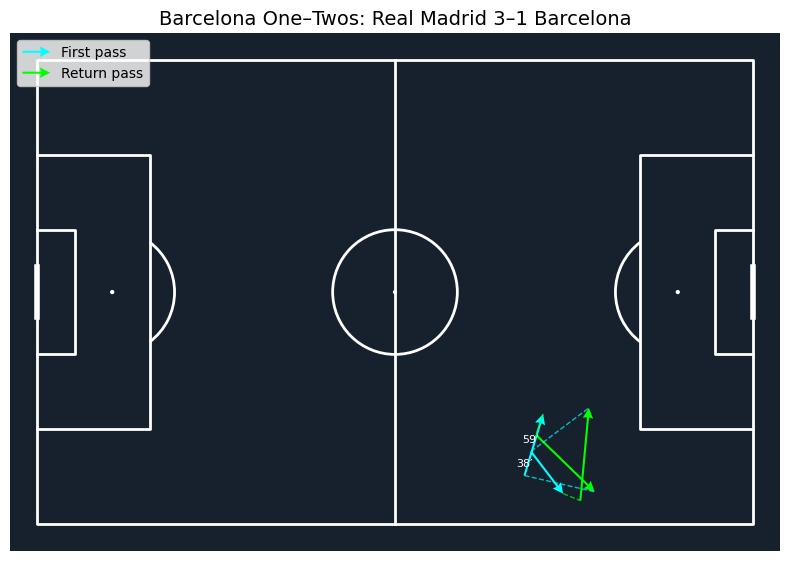

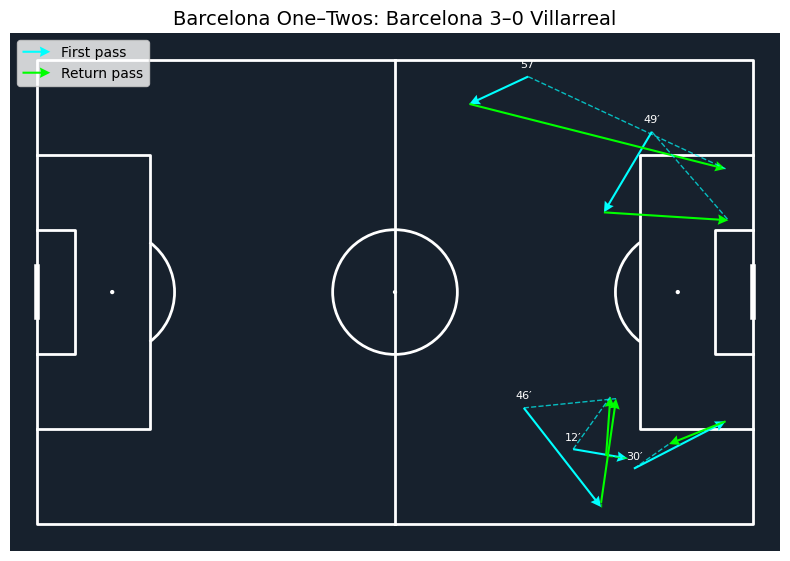

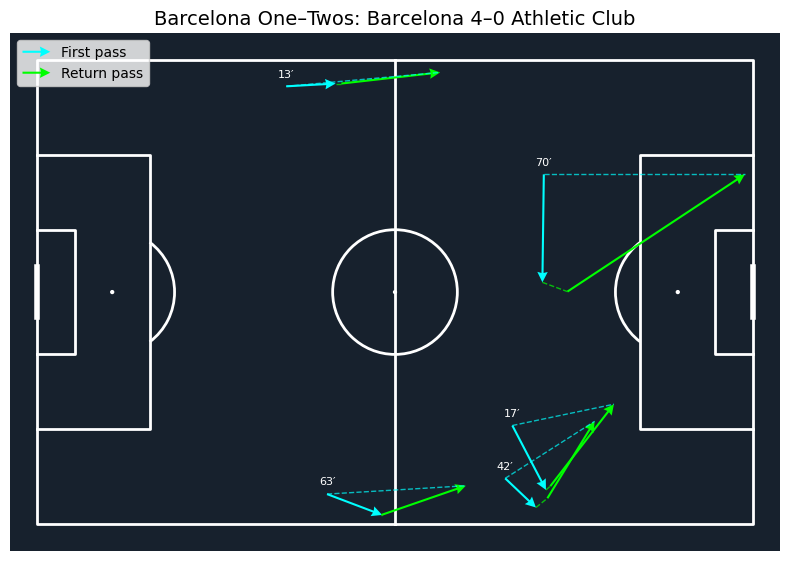

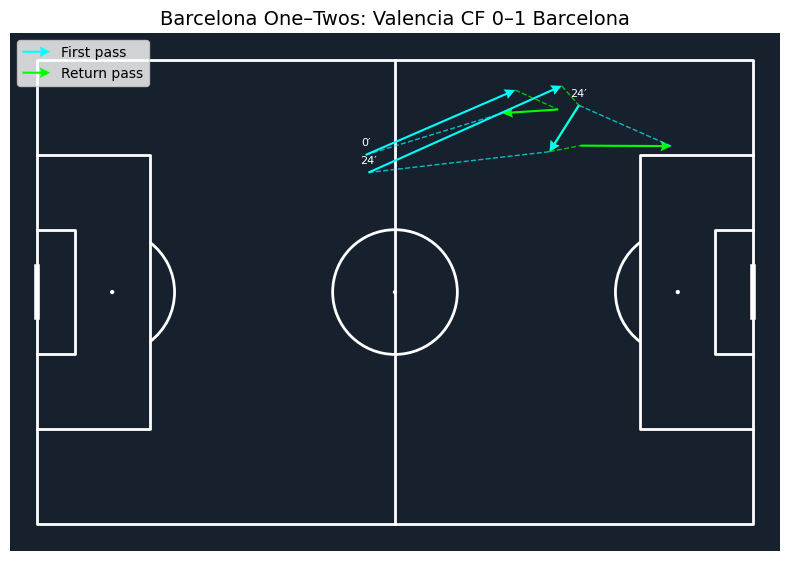

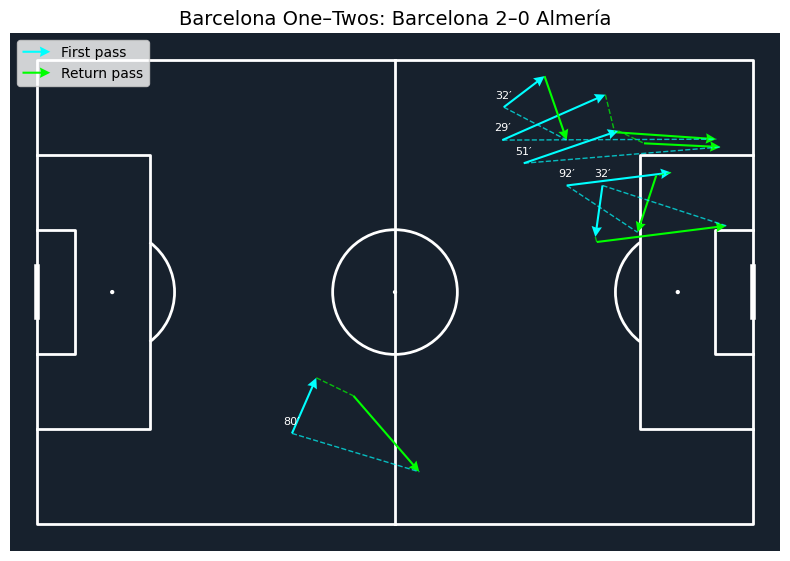

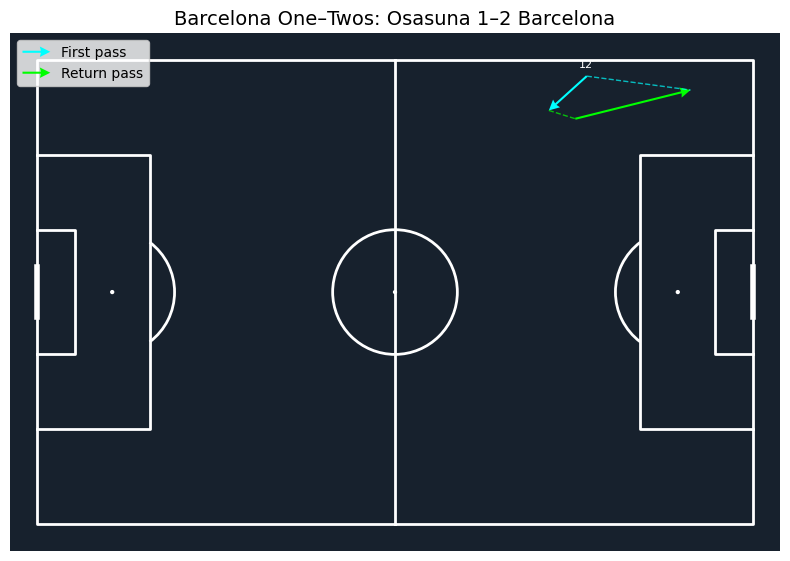

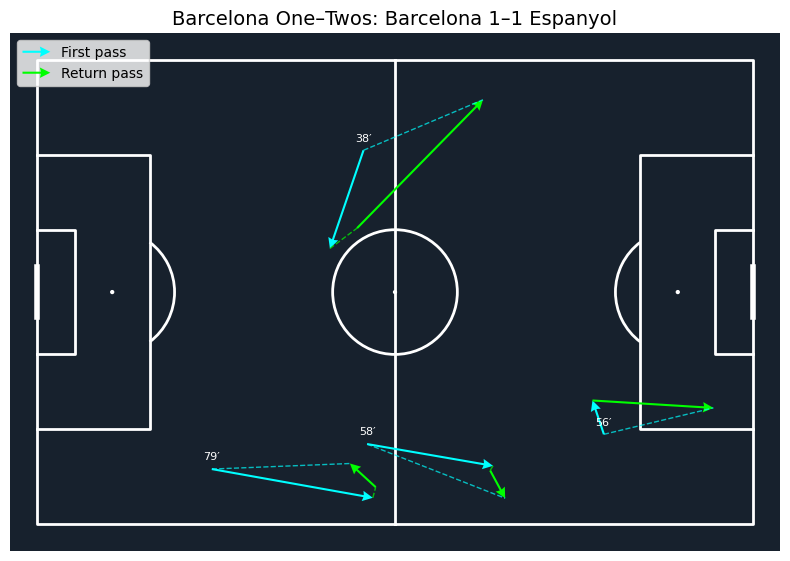

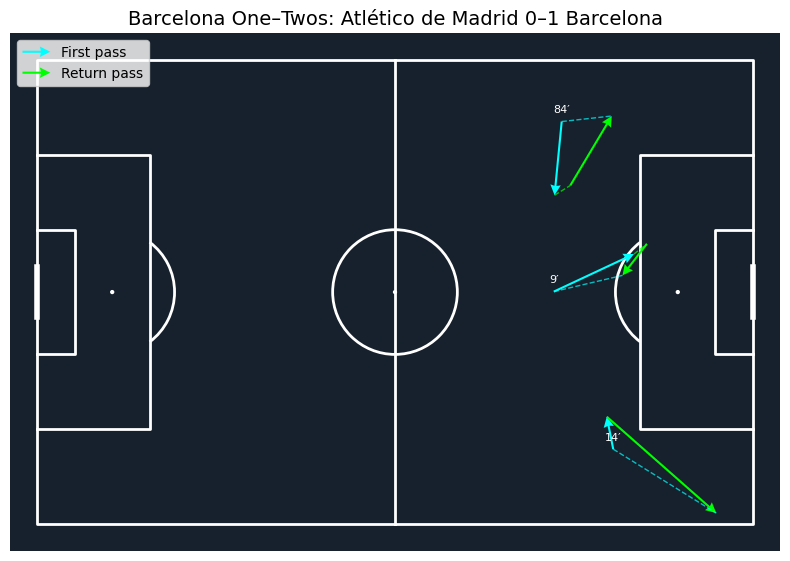

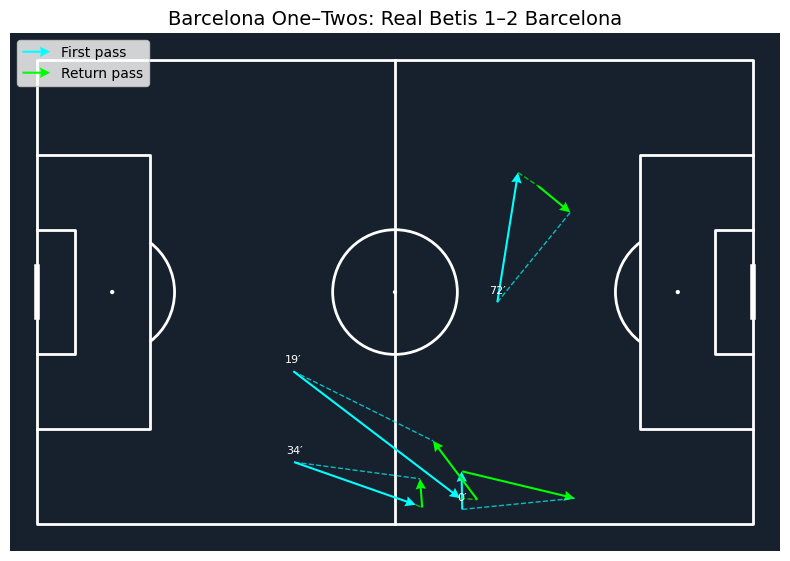

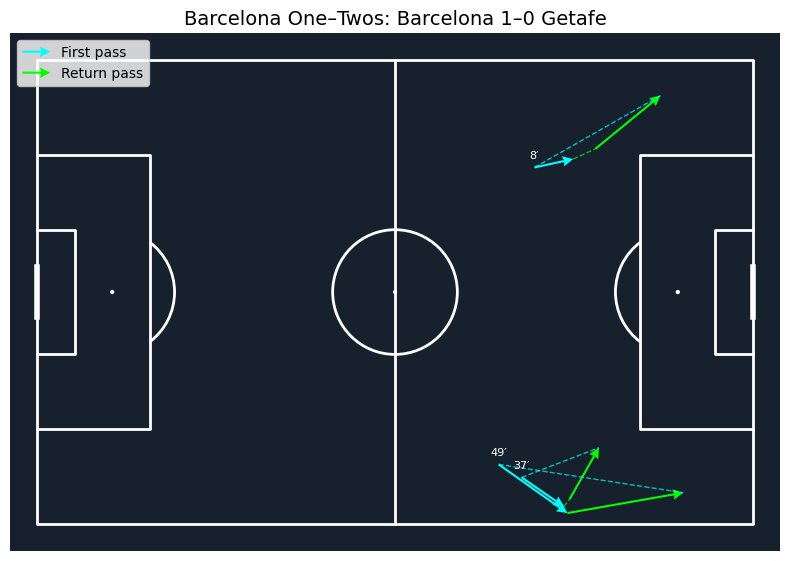

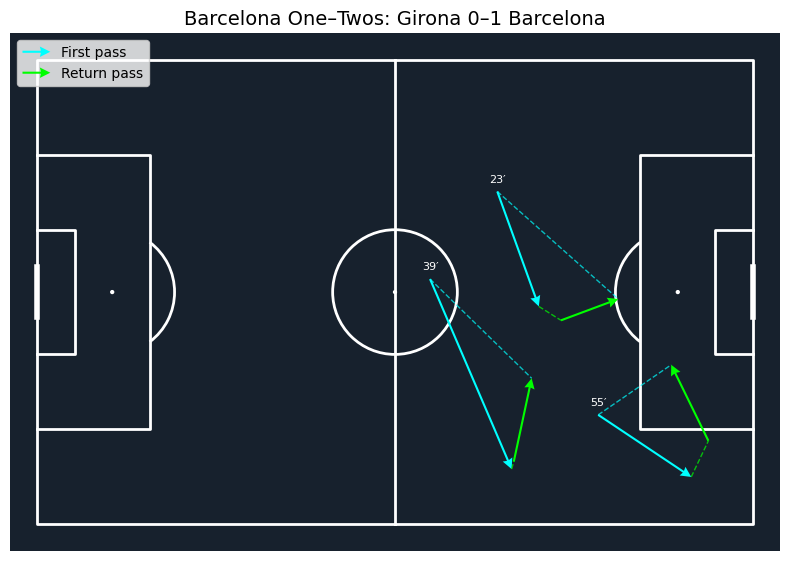

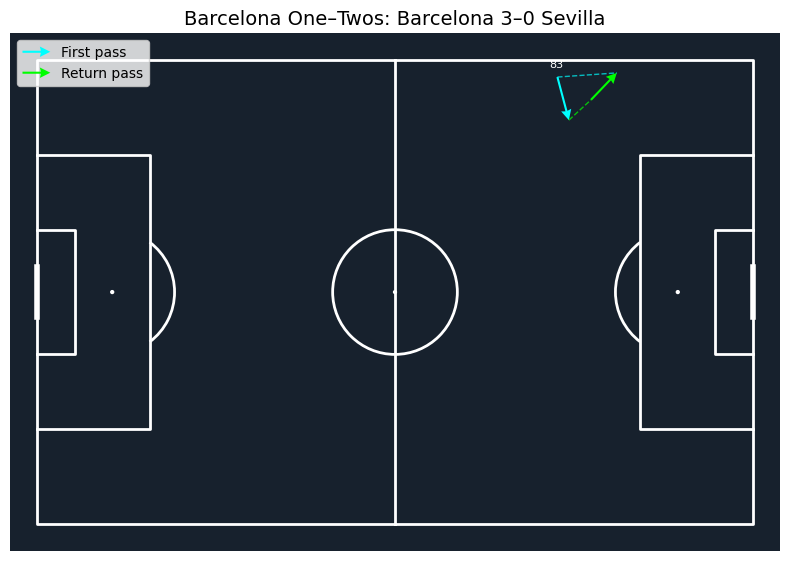

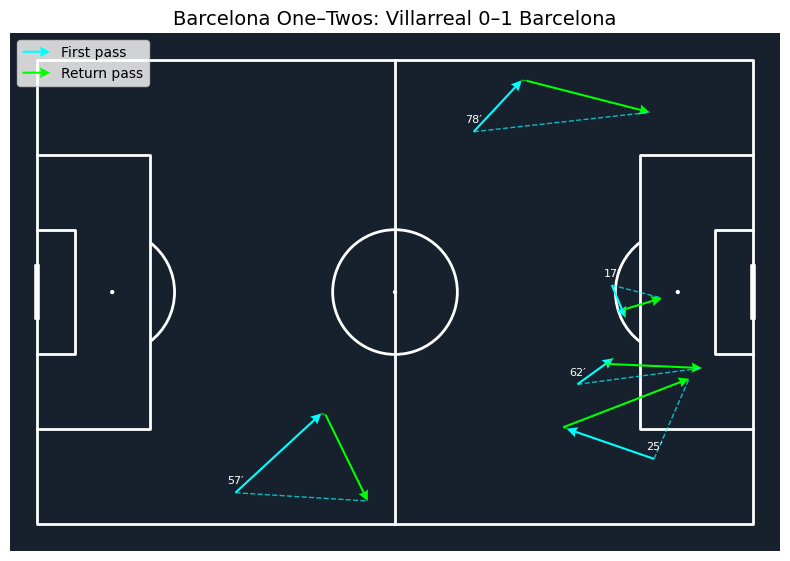

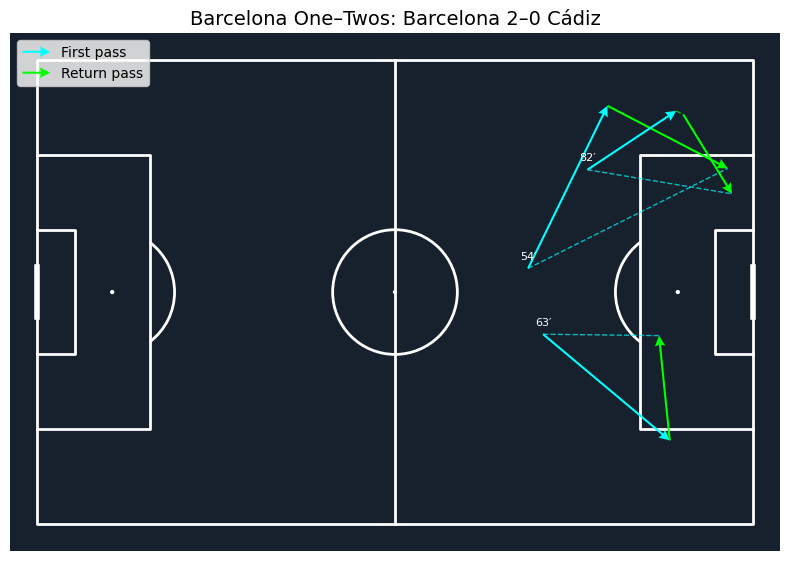

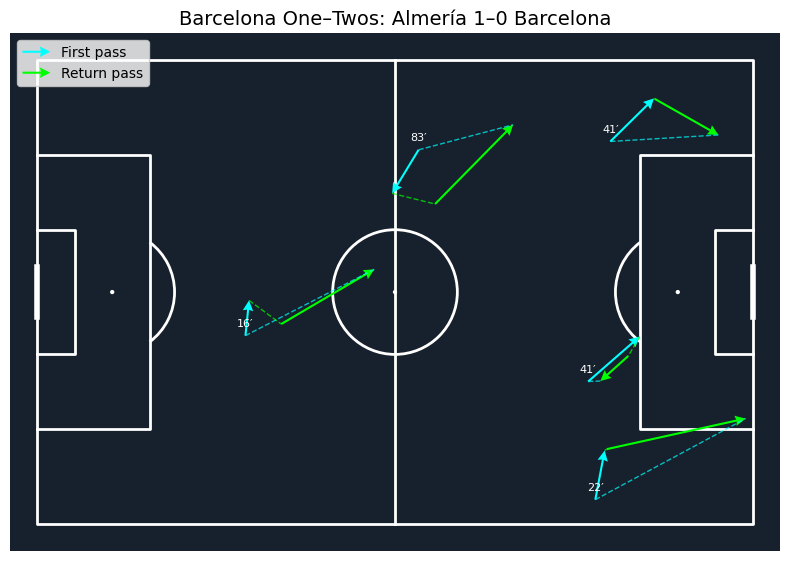

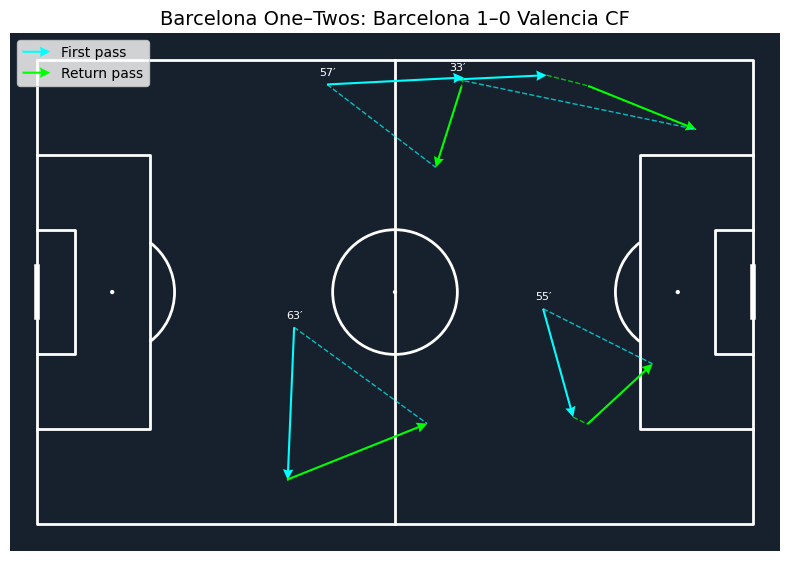

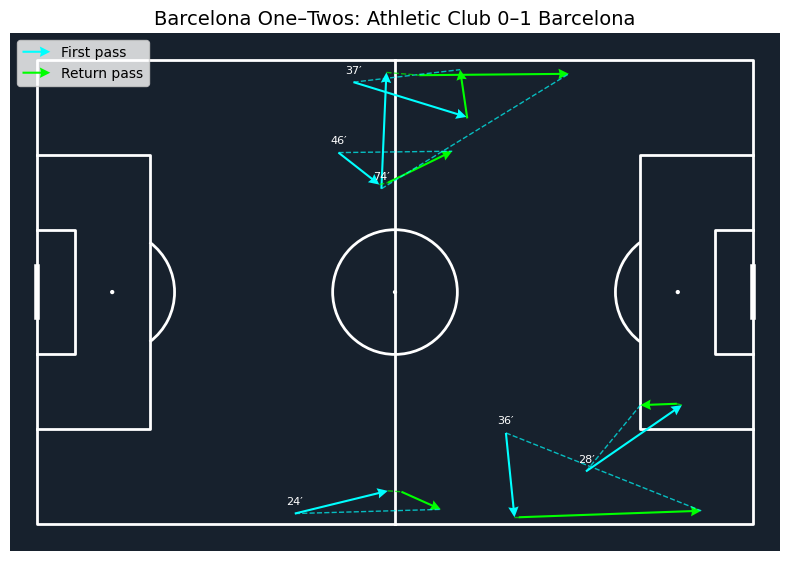

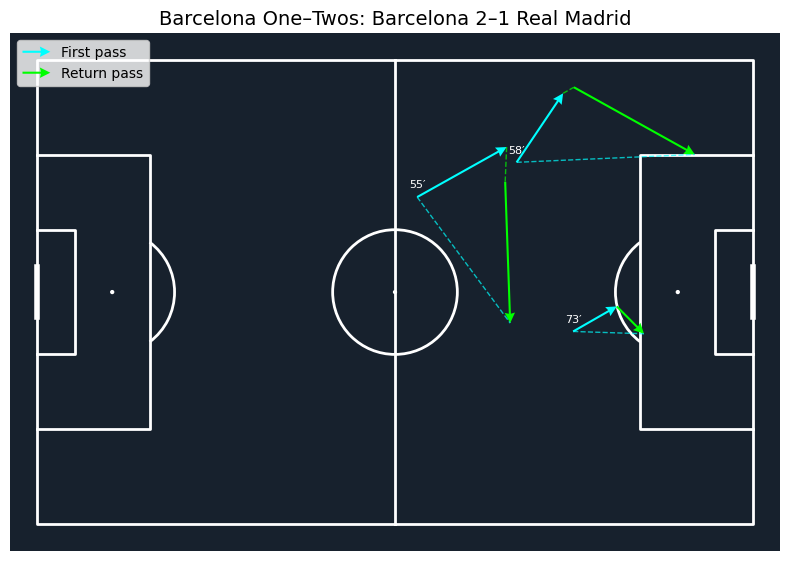

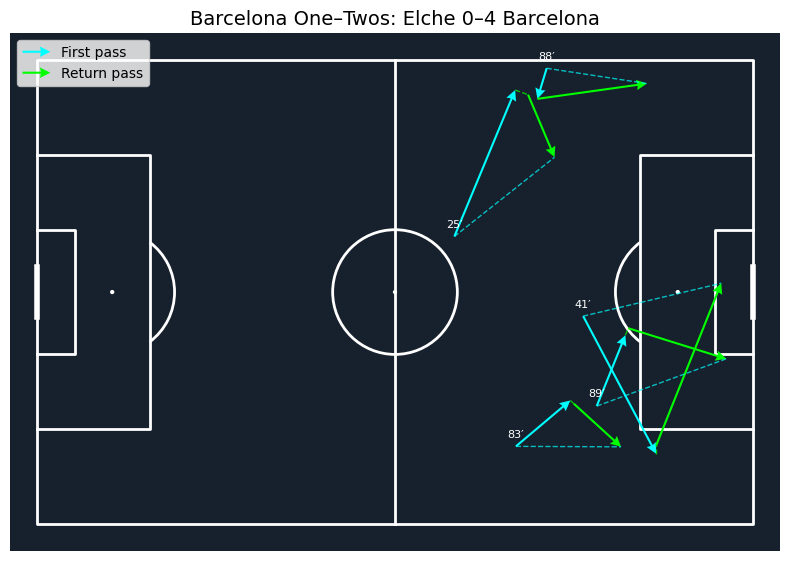

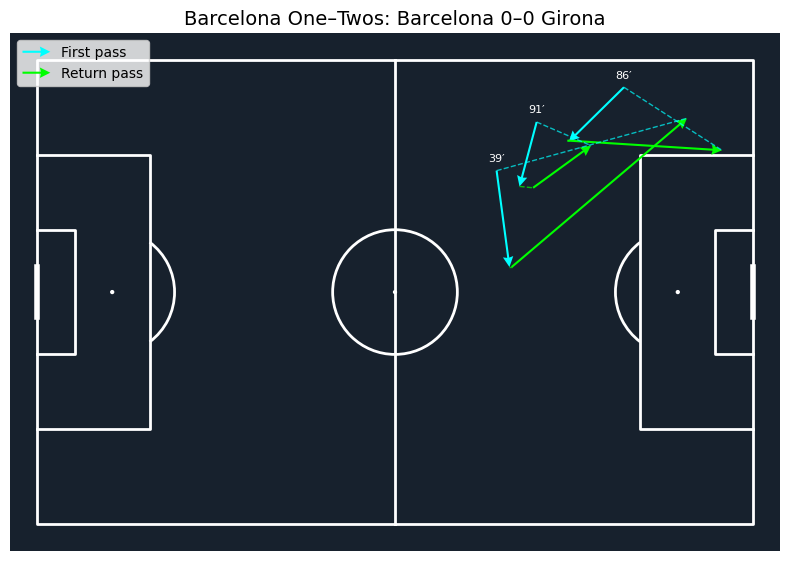

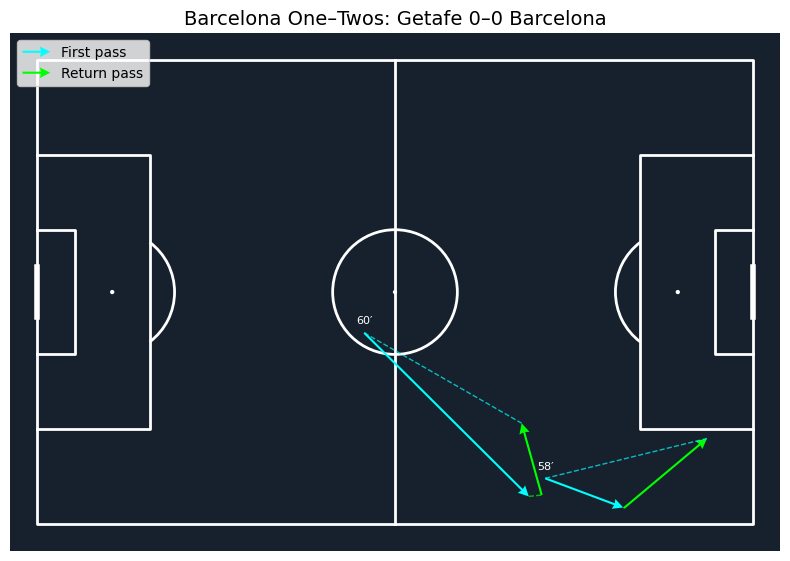

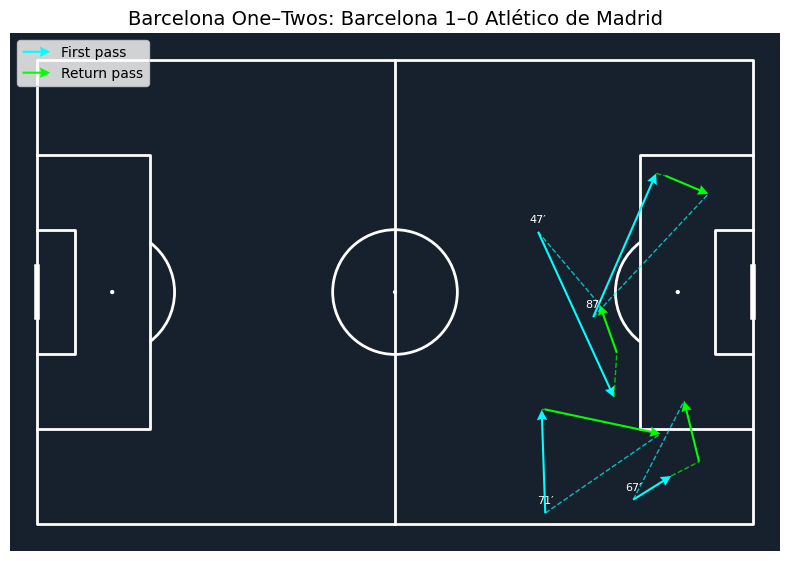

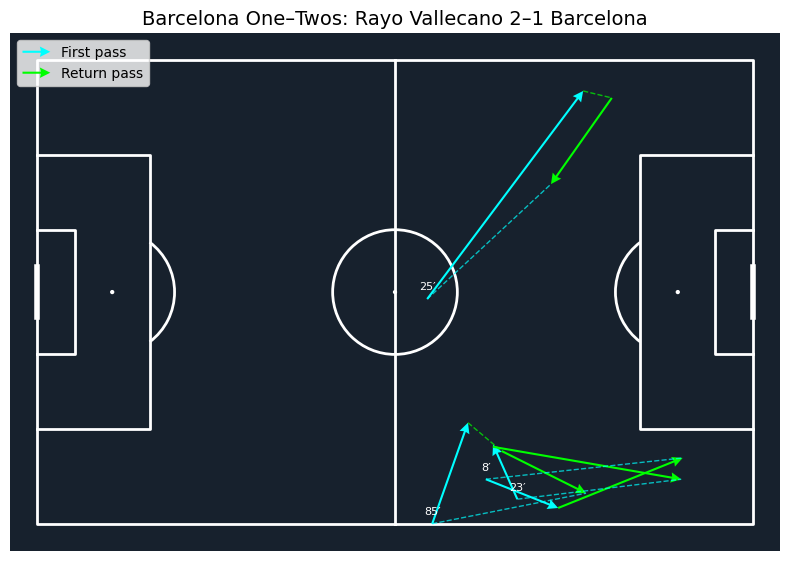

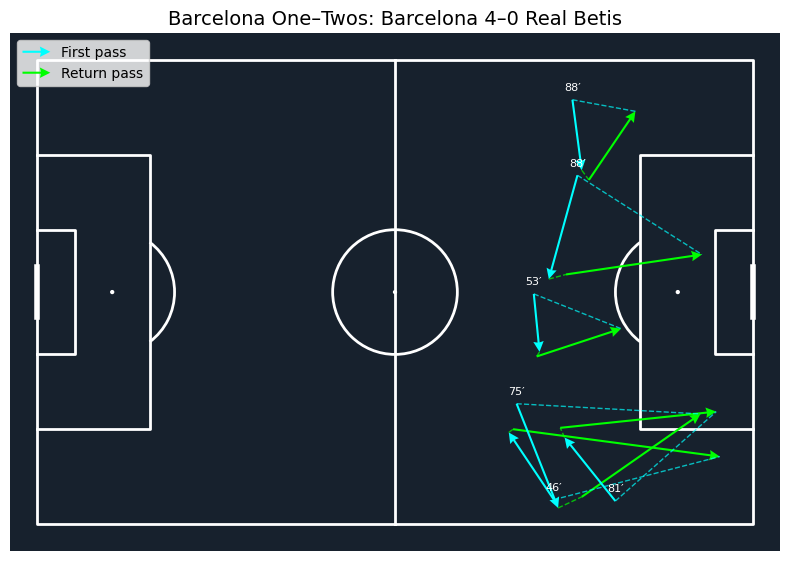

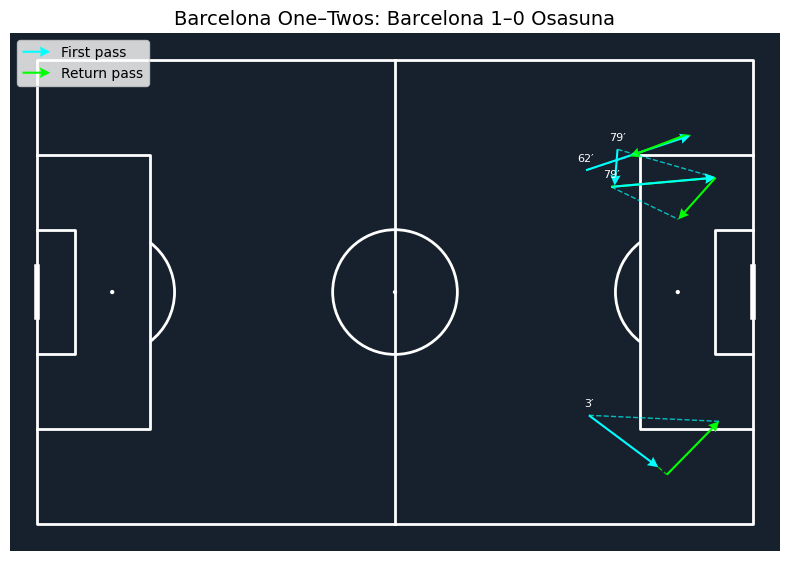

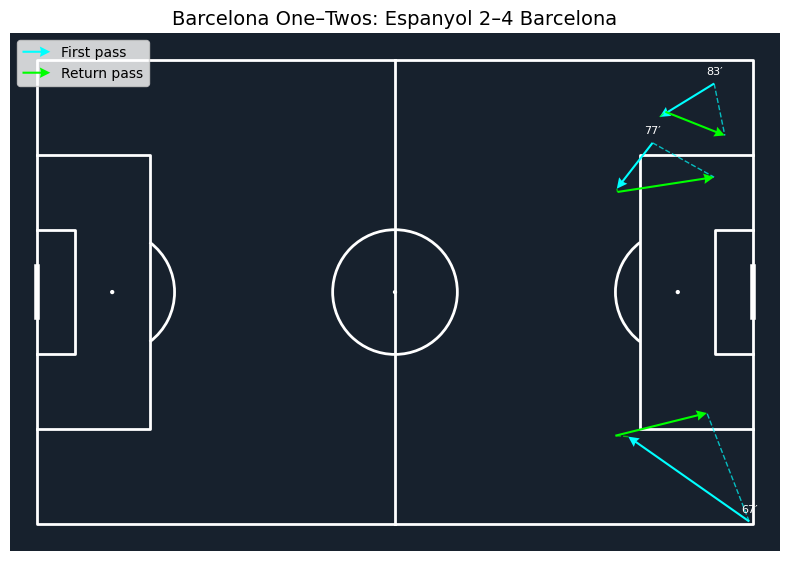

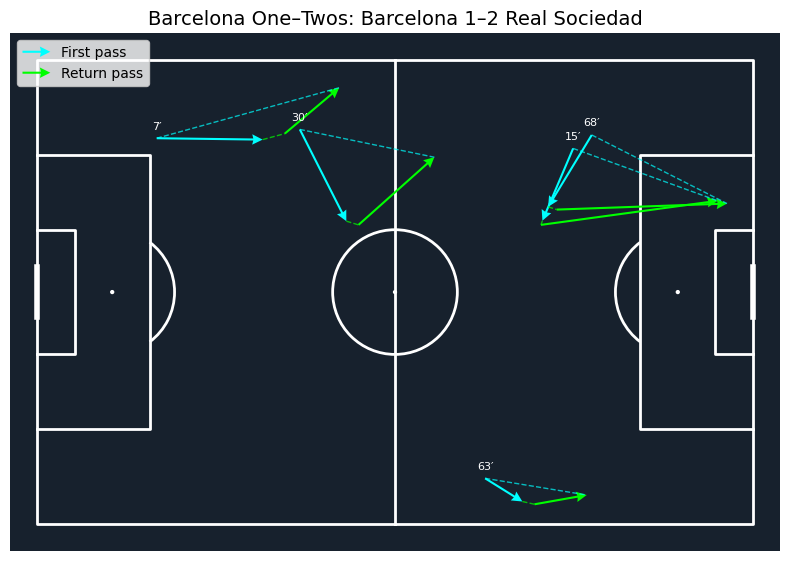

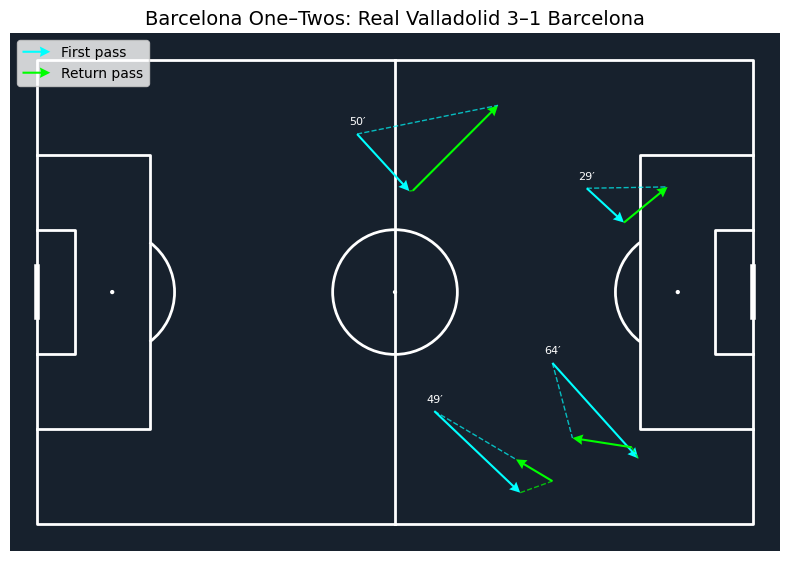

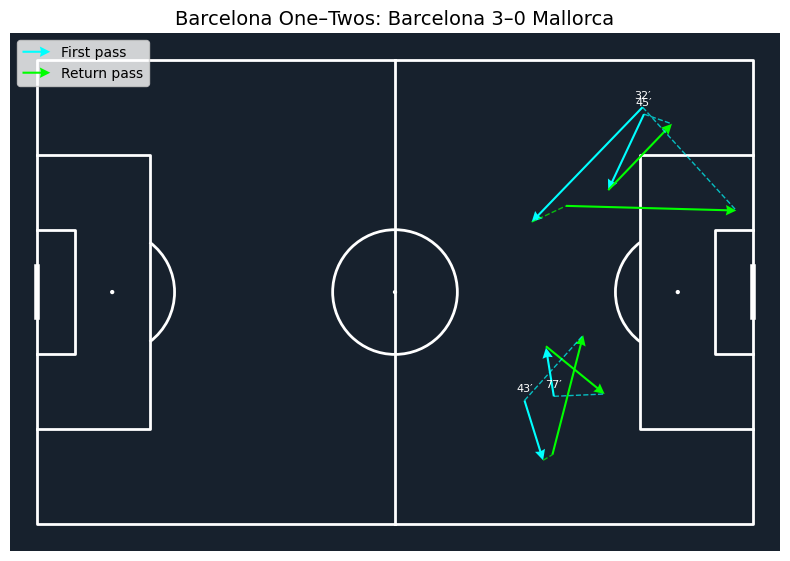

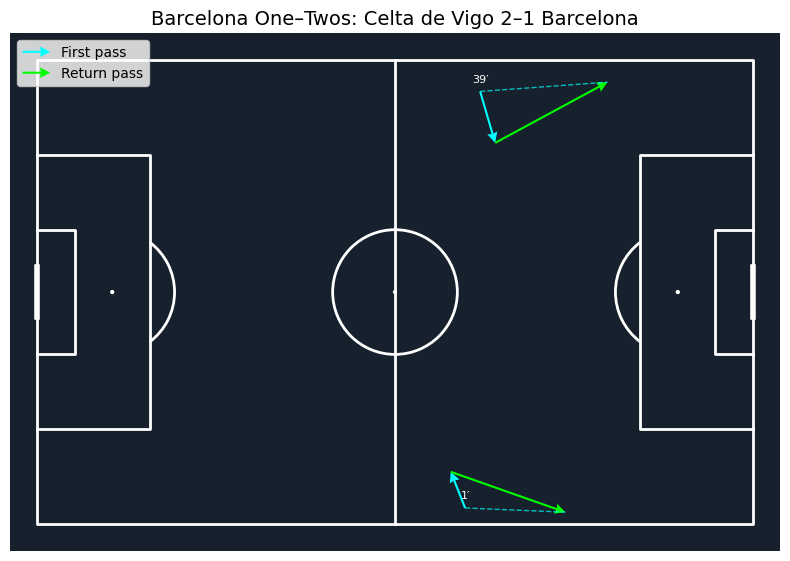

: 

: 

In [ ]:
plot_team_one_twos(progressive_one_twos_df_, "Barcelona")

### One twos rate (team level)

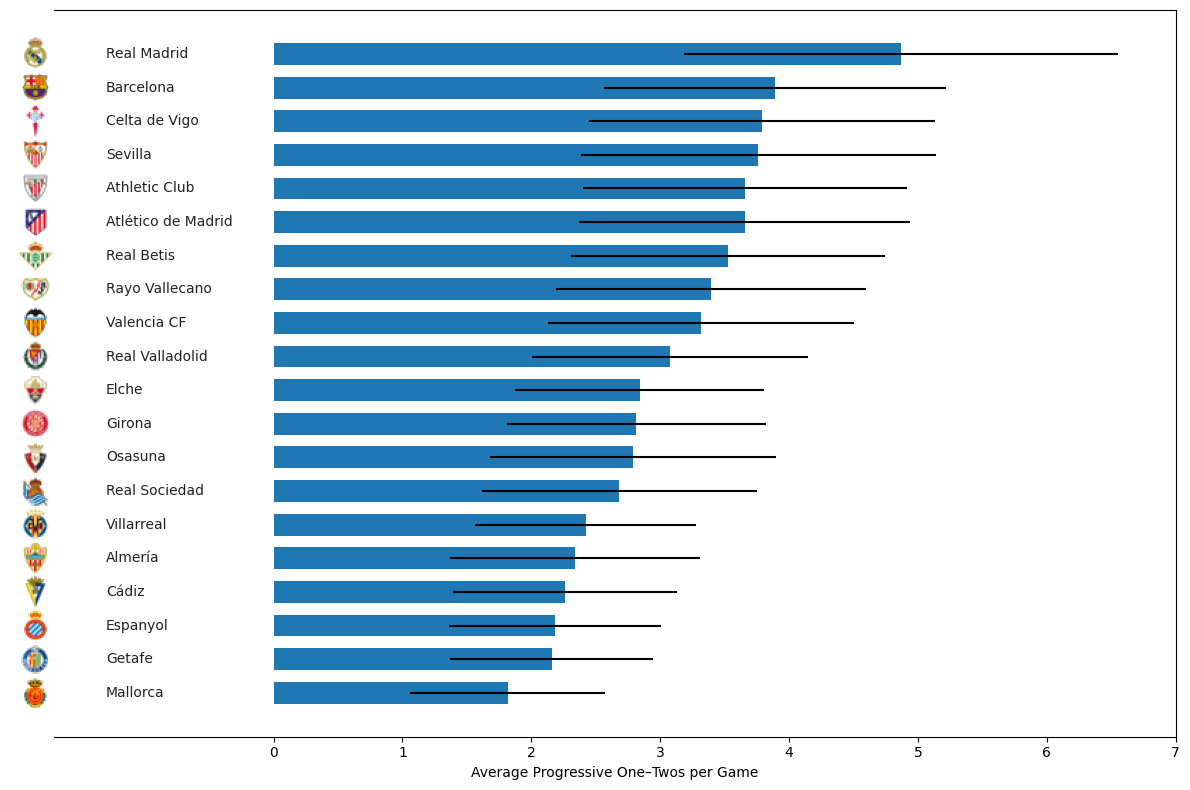

In [7]:
plot_season_avg_one_twos(progressive_one_twos_df_, logos_folder_path)

### One twos spatial distribution

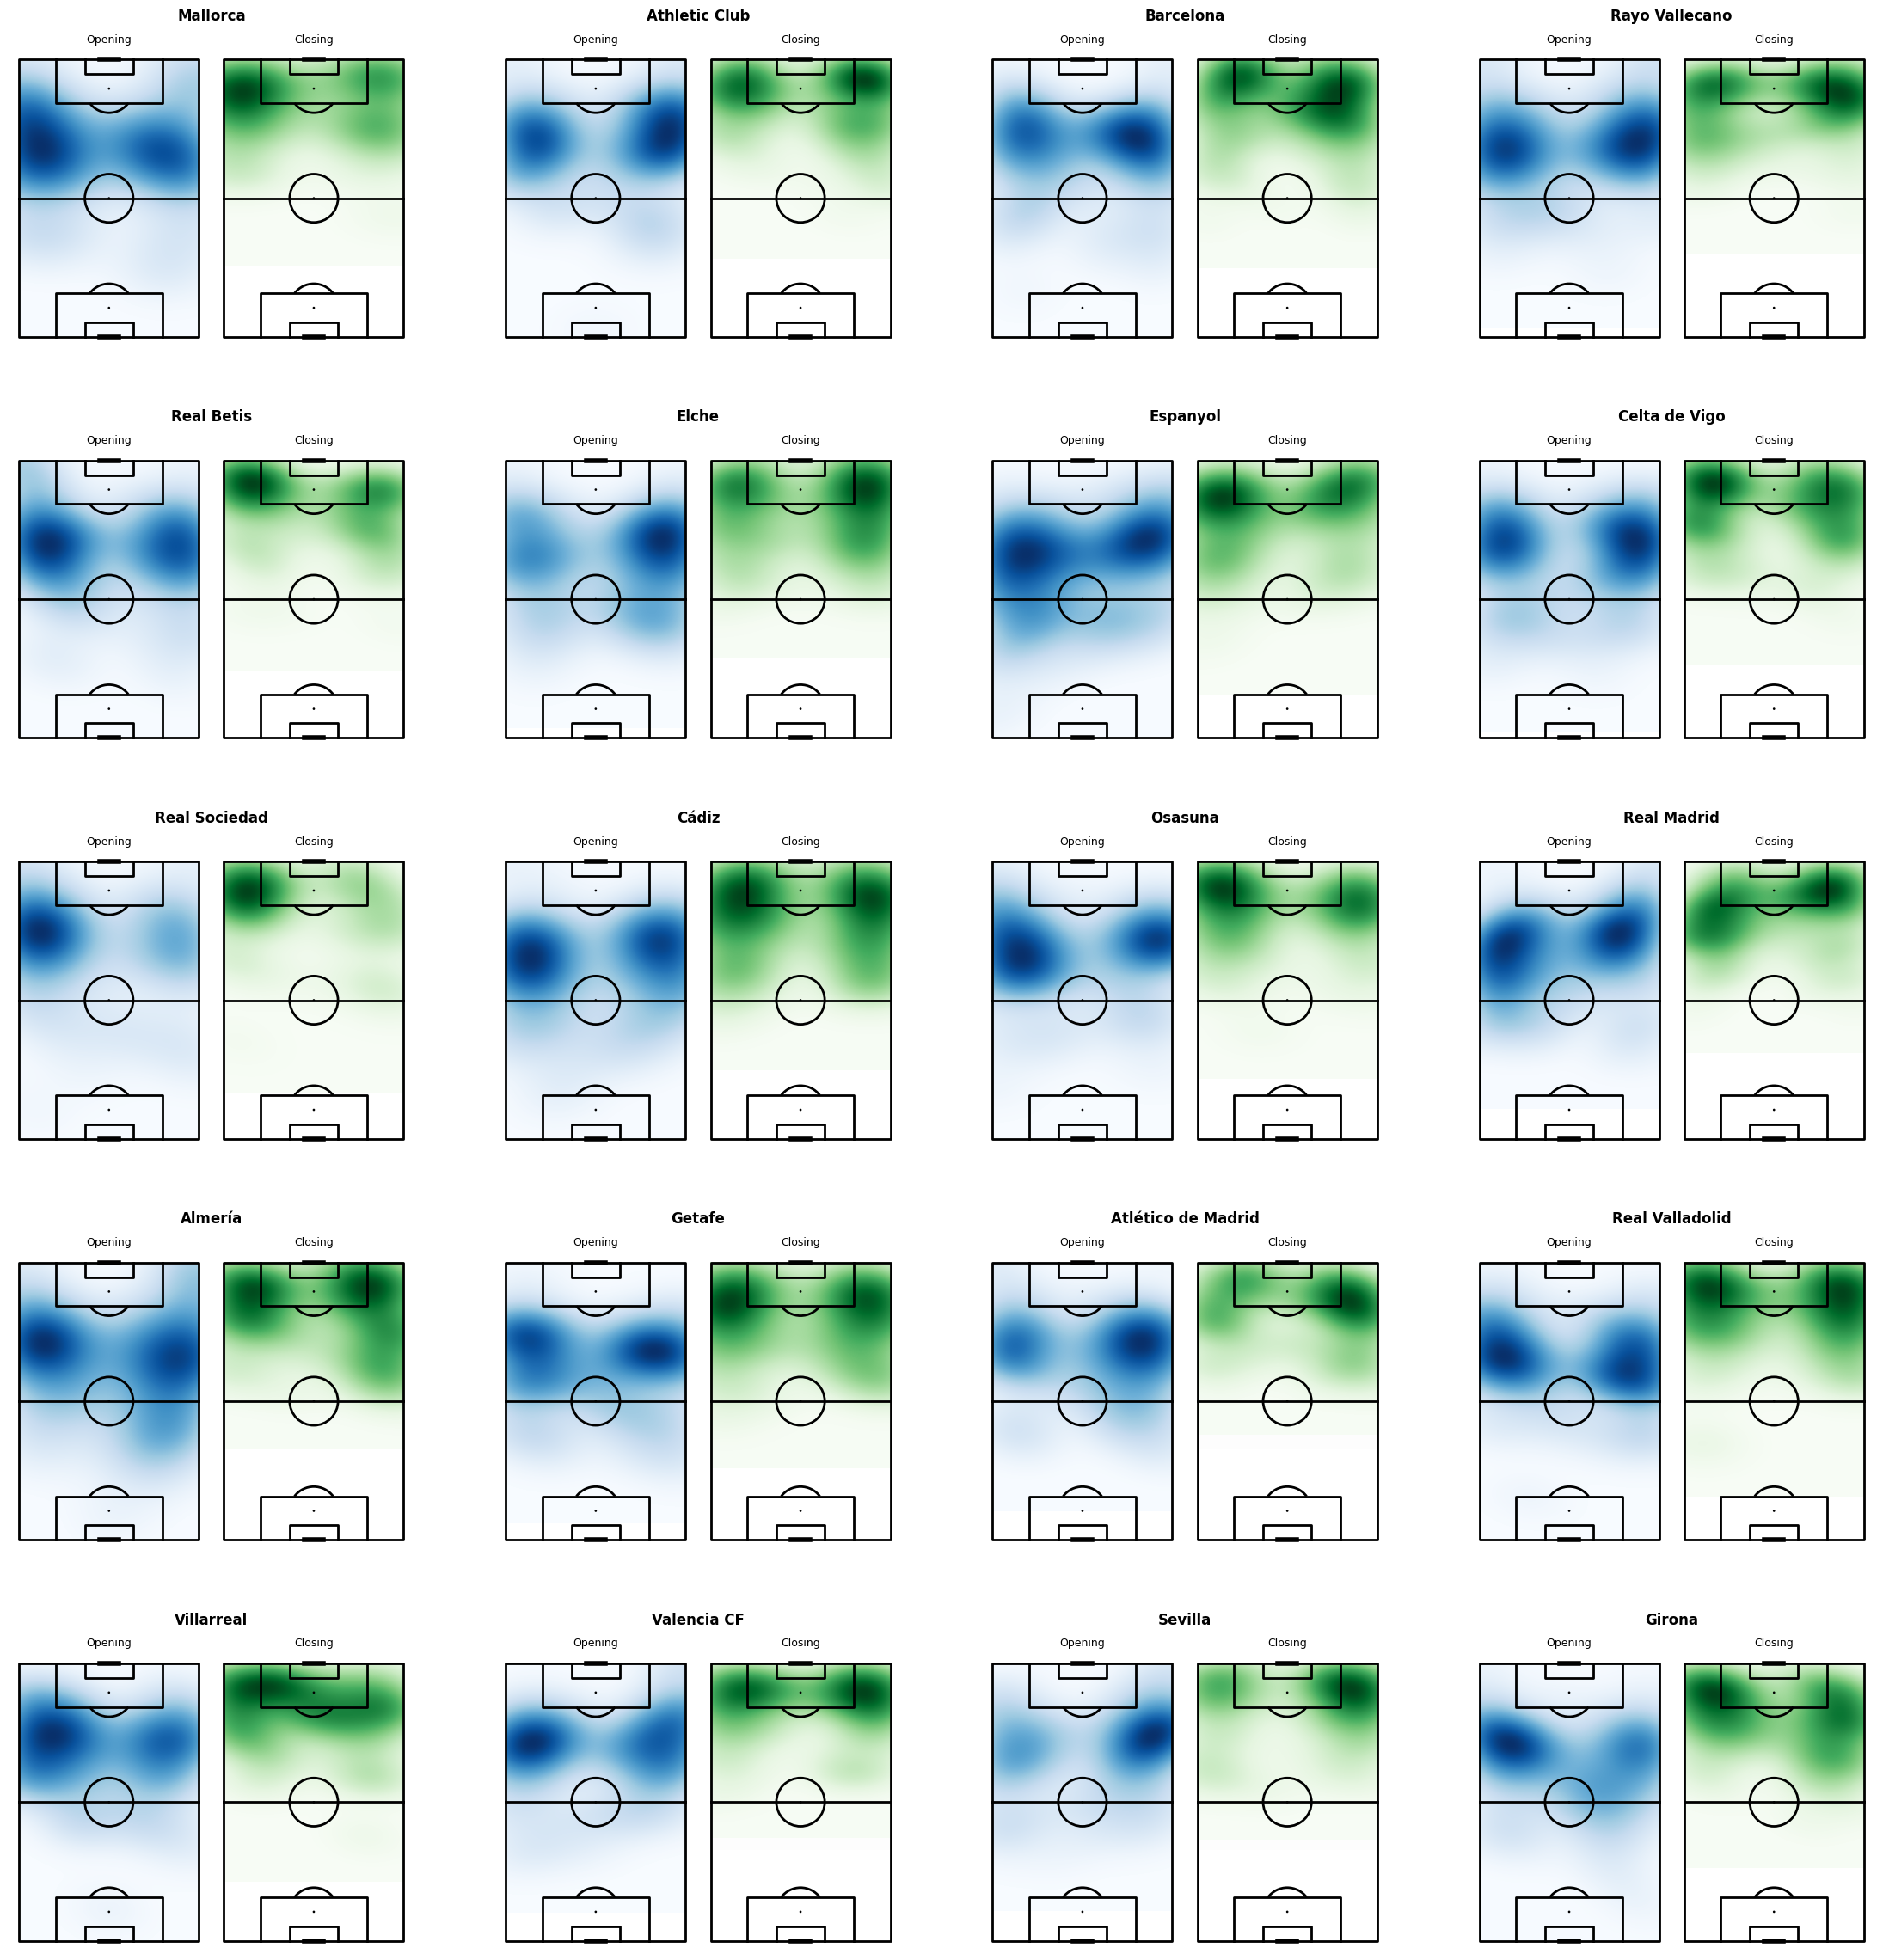

In [8]:
plot_one_twos_heatmap(progressive_one_twos_df_, teams_per_row=4)

### One twos involvement (player level)

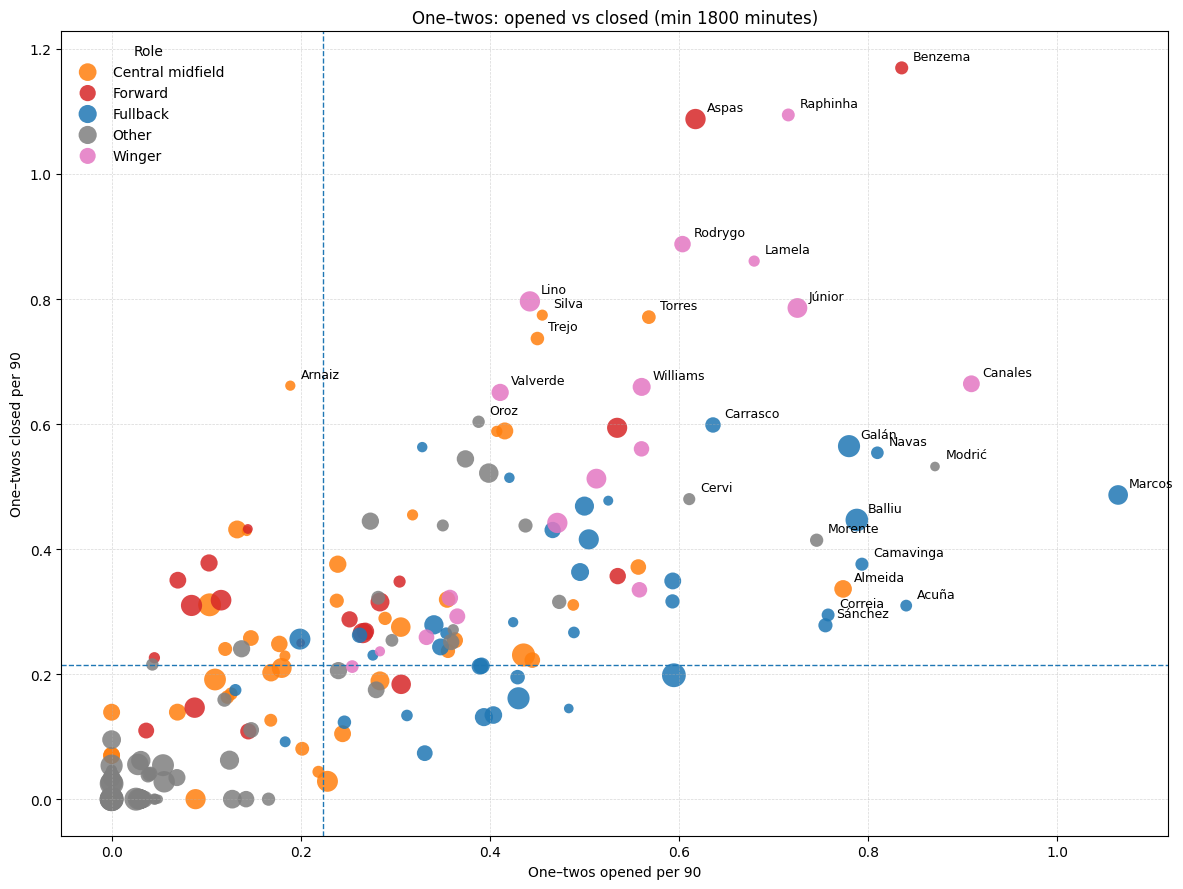

In [9]:
scatter_tbl = plot_onetwos_scatter_player(
    progressive_one_twos_df_, players_df, min_minutes=1800, label_thresh=0.6
)

### One twos duos (player level)
* (Minimum 300 common mins)

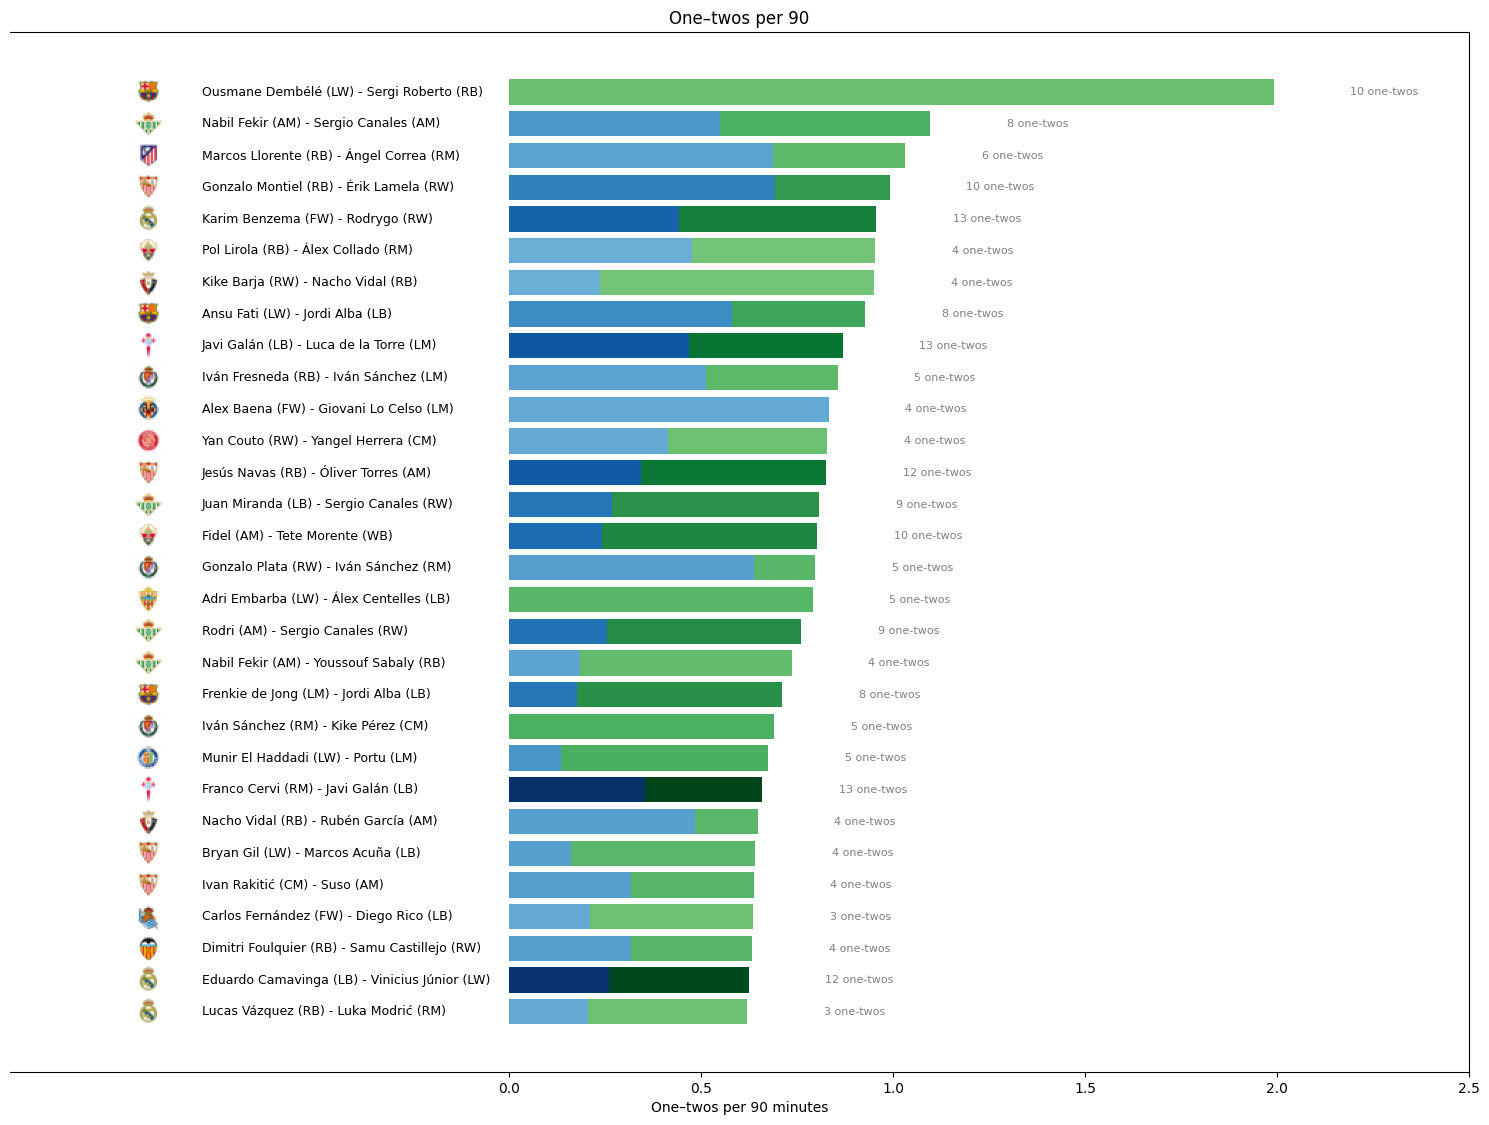

In [10]:
plot_one_twos_per_90(
    onetwos_pairs_df, progressive_one_twos_df_, 360, 30, logos_folder_path
)

### One twos and chance creation (team/competition level)

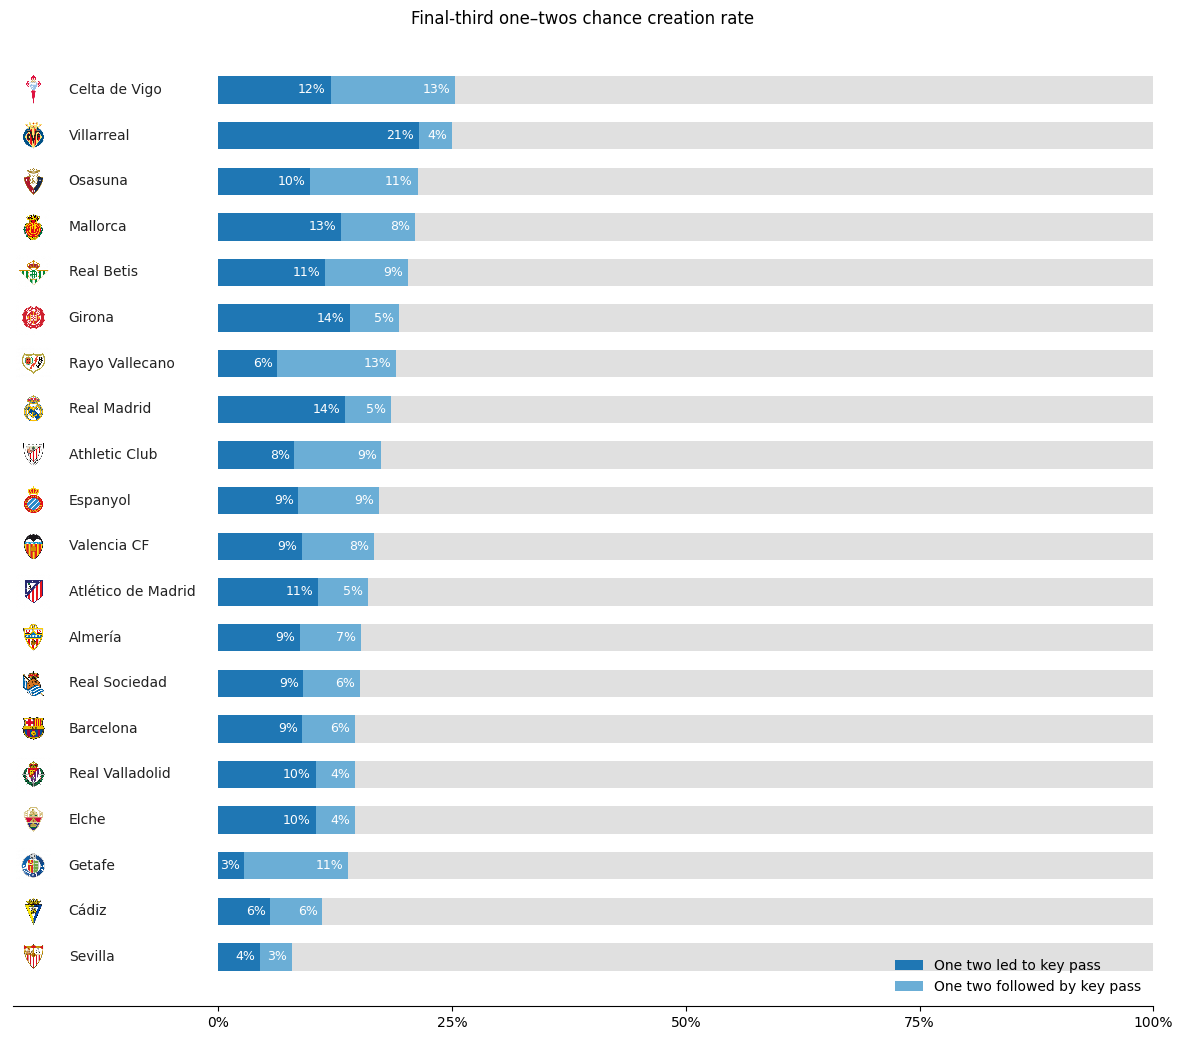

In [11]:
one_twos_chance_creation_stats = plot_onetwos_chance_creation(
    progressive_one_twos_df_, x_thresh=70, logo_folder=logos_folder_path
)